In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

In [4]:
#path = Filepaths.DATA.value / 'high_freq' / 'T4.0'
path = Filepaths.DATA.value / 'convergence' / 'gpu_dt0.005'
data = Data(path)
observ = data.read(['thermo', 'press', 'press_pot', 'born', 'born_nl'], 
                    dropdup=['timestep'], nrows=100_000)
#thermo_data, press_data, press_pot_data, born_data, born_nl_data = dataset.values()
#scale = data.get_scale()
#V = thermo_data.vol.mean()
#T = thermo_data.temp.mean()

In [5]:
observ['T']

np.float64(4.0271127911)

In [13]:
FileKeys.PRESS_POT.value in dataset.keys() and FileKeys.BORN.value in dataset.keys()

True

In [19]:
observ = df2arr(dataset)

In [3]:
trim = len(press_data)

# create 2nd and 4th order tensors out of pressure (stress) and born data
press_raw = np.array(press_data.iloc[:trim,2:]) * scale
stress = -lammps_array_to_matrix(press_raw)
stress_d = stress - stress.mean(axis=0)
press_avg = -np.trace(stress.mean(axis=0)) / 3
# N = stress_d.shape[0]

born_len = min(1_000_000, trim)
press_pot_raw = np.array(press_pot_data.iloc[:born_len,2:]) * scale
press_kin_raw = press_raw[:born_len] - press_pot_raw
stress_kin = -lammps_array_to_matrix(press_kin_raw)
stress_kin_mean = stress_kin.mean(axis=0)

born_raw = np.array(born_data.iloc[:born_len,2:]) * scale / thermo_data.vol[0]
born_voigt = lammps_array_to_matrix(born_raw)
CB = voigt_to_tensor(born_voigt)
CB_avg = CB.mean(axis=0)
CK = -4 * sym_dyad(np.eye(3), stress_kin)
CBK = CB + CK
CBK_avg = CBK.mean(axis=0)

born_nl_raw = np.array(born_nl_data.iloc[:,2:]) * scale / thermo_data.vol[0]
born_nl_voigt = lammps_array_to_matrix(born_nl_raw.reshape(len(born_nl_raw), 21, 6).swapaxes(-1, -2))
NB_avg = voigt_to_tensor(born_nl_voigt, order=3).mean(axis=0)
NK_avg = -sym_dyad(np.eye(3), CBK_avg) / 8
NK_avg += NK_avg.swapaxes(0, 2).swapaxes(1,3) + NK_avg.swapaxes(0, 4).swapaxes(1,5)
NBK_avg = NB_avg + NK_avg

In [5]:
del press_data, born_data, born_raw, born_voigt, press_raw
gc.collect()

11

In [6]:
del born_nl_raw, born_nl_voigt, CBK, CB, CK, press_pot_raw, press_kin_raw, stress_kin
gc.collect()

0

In [7]:
del thermo_data, press_pot_data
gc.collect()

0

In [8]:
del stress
gc.collect()

0

In [5]:
def major_symmetry6(tens):
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -4), -5, -3)
    print('ij<->kl:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -3, -1), -4, -2)
    print('kl<->mn:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -2), -5, -1)
    print('ij<->mn:', np.linalg.norm(tens - tens_t))

print('NK:')
major_symmetry6(NK_avg)

print('NB:')
major_symmetry6(NB_avg)

NK:
ij<->kl: 1.004859174493464e-14
kl<->mn: 0.0
ij<->mn: 1.004859174493464e-14
NB:
ij<->kl: 0.19903297212481433
kl<->mn: 0.0
ij<->mn: 0.19903297212481433


In [5]:
moduli_inf, re = fit_isotropic3(NBK_avg)
for key, value in moduli_inf.items():
    print(f"{key}: {value:.1f}")
print(f"rel.err.: {re:.2e}")

A: -359.0
B: -734.6
C: -2978.1
rel.err.: 1.40e-03


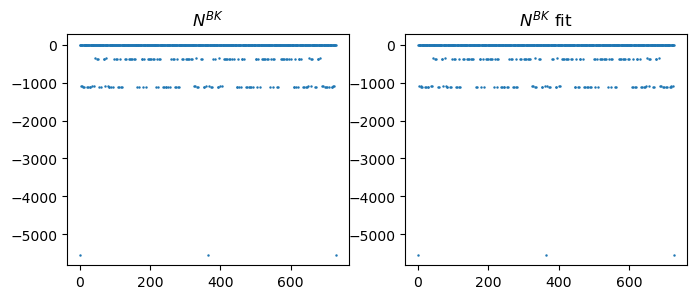

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(NBK_avg.flatten(), '.', ms=1.5)
ax[0].set_title(r"$N^{BK}$")
ax[1].plot(isotropic3(moduli_inf).flatten(), '.', ms=1.5)
ax[1].set_title(r"$N^{BK}$ fit")
plt.show()

# Correlation 3

In [4]:
stress_d.shape

(50000001, 3, 3)

In [12]:
s3 = 0
step_size = 10
steps = len(stress_d) // step_size - 1
chunks = 100
steps_chunk = steps // chunks
print(f"Steps number: {steps}")
for j, _ in enumerate(ProgressBarText(range(chunks), 25)):
    for k in range(steps_chunk):
        i = j * steps_chunk + k
        s = stress_d[i*step_size:(i+1)*step_size, 0, 0].copy()
        s3 += corr3_fast(s).real / steps

Steps number: 4999999
Progress: |█████████████████████████| 100.0% Elapsed: 0:07:50, Estimated: 0:07:50


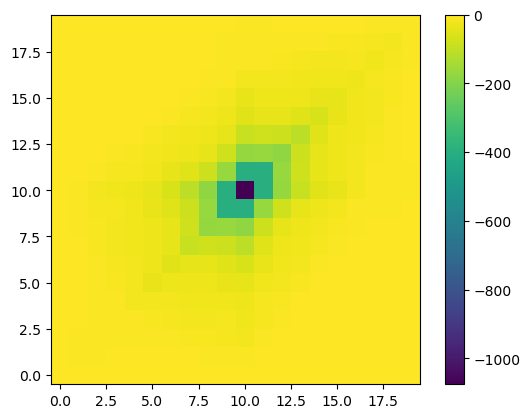

In [13]:
data = V**2 / 2 / T**2 * np.fft.fftshift(s3.T)
plt.imshow(data, origin='lower')
plt.colorbar()

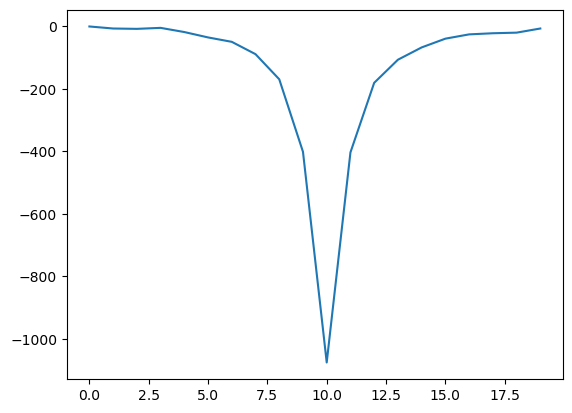

In [14]:
plt.plot([data[i,i] for i in range(2*step_size)])

In [15]:
np.savetxt(path / 'corr3_xx_step10', data)